In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv
/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv
/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv
/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv


In [5]:
df1 = pd.read_csv('/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv')
df2 = pd.read_csv('/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv')
df3 = pd.read_csv('/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv')
df4 = pd.read_csv('/kaggle/input/aadhar-biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv')

In [6]:
df1.shape, df2.shape, df3.shape, df4.shape

((500000, 6), (500000, 6), (361108, 6), (500000, 6))

In [7]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [8]:
df.shape

(1861108, 6)

In [9]:
df

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,19-09-2025,Goa,North Goa,403502,0,4
1,19-09-2025,Goa,North Goa,403508,1,4
2,19-09-2025,Goa,North Goa,403513,2,0
3,19-09-2025,Goa,North Goa,403527,2,2
4,19-09-2025,Goa,South Goa,403601,7,3
...,...,...,...,...,...,...
1861103,08-12-2025,Gujarat,Vadodara,391150,3,18
1861104,08-12-2025,Gujarat,Vadodara,391168,11,34
1861105,08-12-2025,Gujarat,Vadodara,391170,0,23
1861106,08-12-2025,Gujarat,Vadodara,391410,9,4


# imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [8]:
# Set style for publication-ready plots
plt.rcParams.update({'font.size': 10})
sns.set_style("whitegrid")

# Key Analyses & Visualizations

# use pandas profiling 

In [9]:
# !pip install ydata-profiling

In [10]:
# import pandas as pd
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df, title="Data Profiling Report")

In [11]:
# profile.to_file("data_report.html")

# Start over

## preprocessing

In [12]:
# Ensure date is parsed correctly
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

# Extract time features (as per profiling: year=2025, month=3-12, day_of_week=0-6)
df['year'] = df['date'].dt.year  # Constant 2025 → confirmed by profiling
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # Mon=0, Sun=6

# Create derived columns
df['total_bio'] = df['bio_age_5_17'] + df['bio_age_17_']
df['minor_ratio'] = df['bio_age_5_17'] / (df['total_bio'] + 1e-9)  # Avoid division by zero

# Drop duplicates if needed (profiling shows 5.1% duplicates — may be intentional for aggregation)
# Uncomment if you want to deduplicate
# df = df.drop_duplicates().reset_index(drop=True)

# Optional: Add day name for readability
df['day_name'] = df['date'].dt.day_name()

## Visualizations and analysis

### A. Total Updates Over Time (Daily Trend)

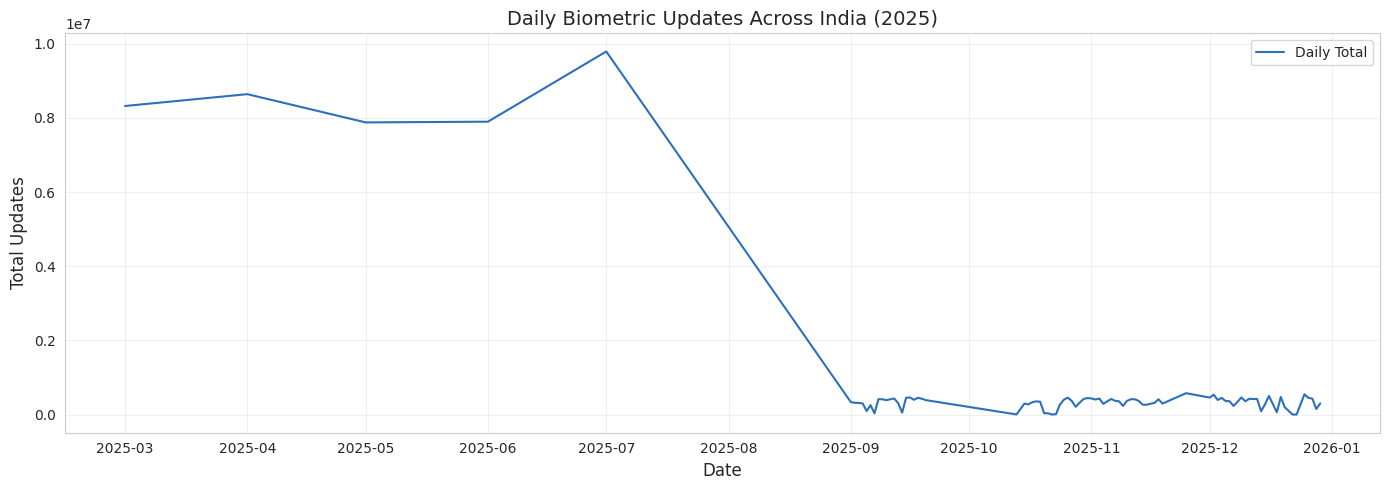

In [13]:
daily_total = df.groupby('date')['total_bio'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_total['date'], daily_total['total_bio'], color='#2C6FBB', linewidth=1.5, label='Daily Total')
plt.title('Daily Biometric Updates Across India (2025)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Updates', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('daily_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### B. Age Group Distribution: Minor vs Adult

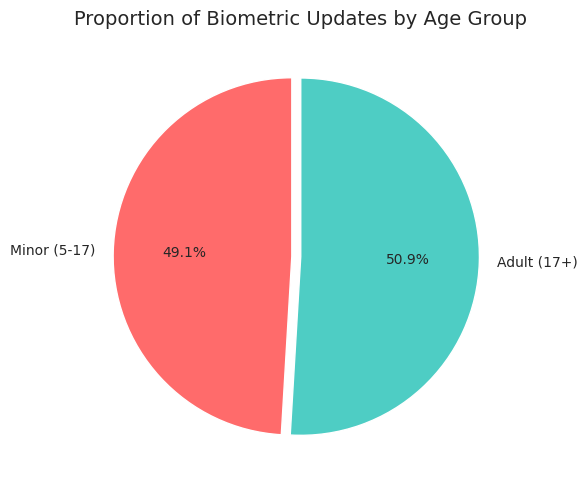

In [14]:
age_groups = df[['bio_age_5_17', 'bio_age_17_']].sum()
labels = ['Minor (5-17)', 'Adult (17+)']
colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(8, 5))
plt.pie(age_groups, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0))
plt.title('Proportion of Biometric Updates by Age Group', fontsize=14)
plt.tight_layout()
plt.savefig('age_group_pie.png', dpi=300, bbox_inches='tight')
plt.show()

### C. Top 10 States by Total Updates

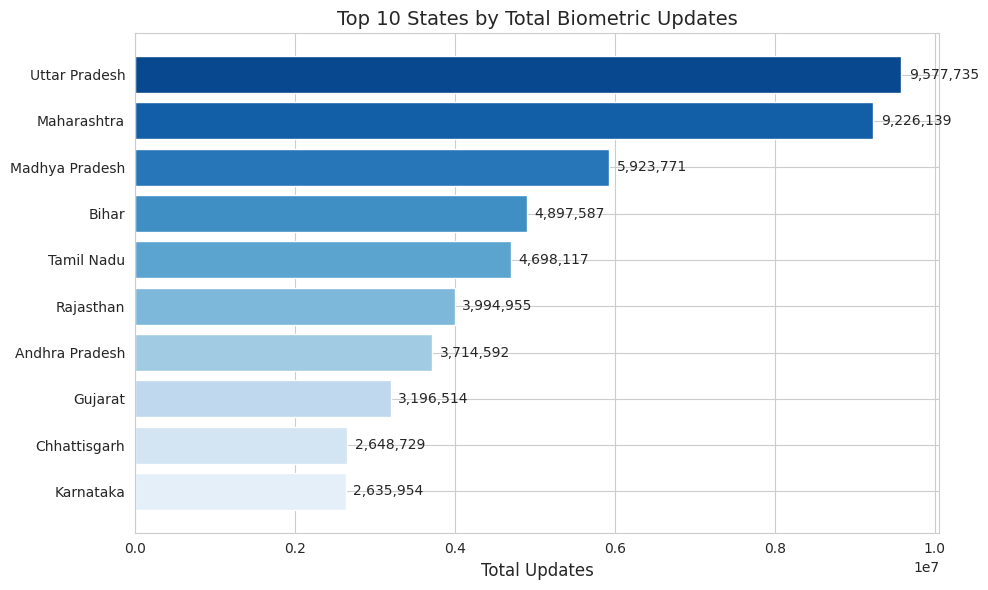

In [15]:
state_updates = df.groupby('state')['total_bio'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.barh(state_updates['state'], state_updates['total_bio'], color=sns.color_palette("Blues_r", len(state_updates)))
plt.title('Top 10 States by Total Biometric Updates', fontsize=14)
plt.xlabel('Total Updates', fontsize=12)
plt.gca().invert_yaxis()  # Highest on top

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01 * max(state_updates['total_bio']), bar.get_y() + bar.get_height()/2, f'{int(width):,}', ha='left', va='center')

plt.tight_layout()
plt.savefig('top_states.png', dpi=300, bbox_inches='tight')
plt.show()

### D. Minor Ratio by State (Focus on Youth Engagement)

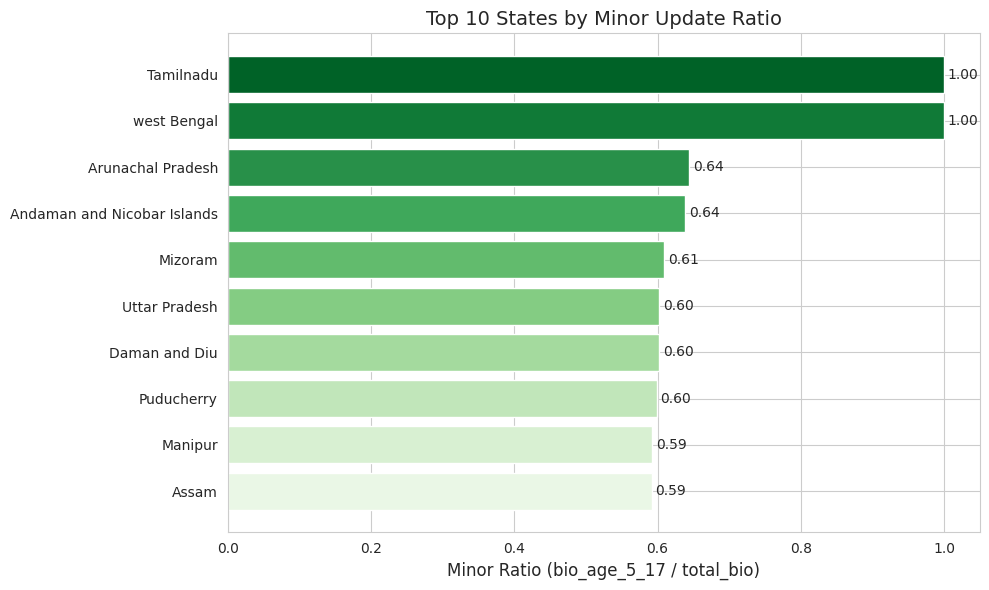

In [16]:
state_minor_ratio = df.groupby('state')['minor_ratio'].mean().reset_index().nlargest(10, 'minor_ratio')

plt.figure(figsize=(10, 6))
bars = plt.barh(state_minor_ratio['state'], state_minor_ratio['minor_ratio'], color=sns.color_palette("Greens_r", len(state_minor_ratio)))
plt.title('Top 10 States by Minor Update Ratio', fontsize=14)
plt.xlabel('Minor Ratio (bio_age_5_17 / total_bio)', fontsize=12)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.2f}', ha='left', va='center')

plt.tight_layout()
plt.savefig('minor_ratio_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

### E. Day-of-Week Pattern (Are Weekends Busier?)

/tmp/ipykernel_55/2587092214.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_updates, x='day_name', y='total_bio', palette='viridis')


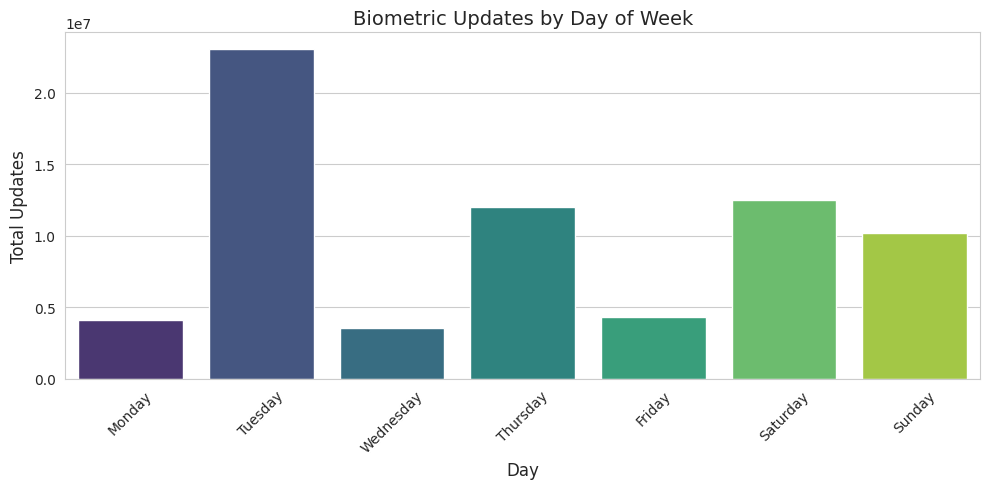

In [17]:
day_updates = df.groupby('day_name')['total_bio'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=day_updates, x='day_name', y='total_bio', palette='viridis')
plt.title('Biometric Updates by Day of Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Total Updates', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('day_of_week.png', dpi=300, bbox_inches='tight')
plt.show()

### G. Anomaly Detection: Zero Updates for Minors in High-Activity Areas


🔍 Potential Anomalies (Zero Minor Updates but High Adult Activity):
              state    district  pincode  bio_age_5_17  bio_age_17_  total_bio
161226  Maharashtra  Gadchiroli   442603             0          101        101
171851        Delhi  North East   110094             0           51         51
220887  Maharashtra     Buldana   444303             0           71         71
343010  Maharashtra     Buldana   443101             0           56         56
357680  Maharashtra     Buldana   444203             0           60         60
359899        Delhi  North East   110094             0           53         53
366761  Maharashtra     Buldana   443301             0           55         55
375168  Maharashtra     Buldana   443302             0           57         57
388383  Maharashtra     Buldana   443301             0           79         79
404389  Maharashtra     Buldana   443302             0           52         52


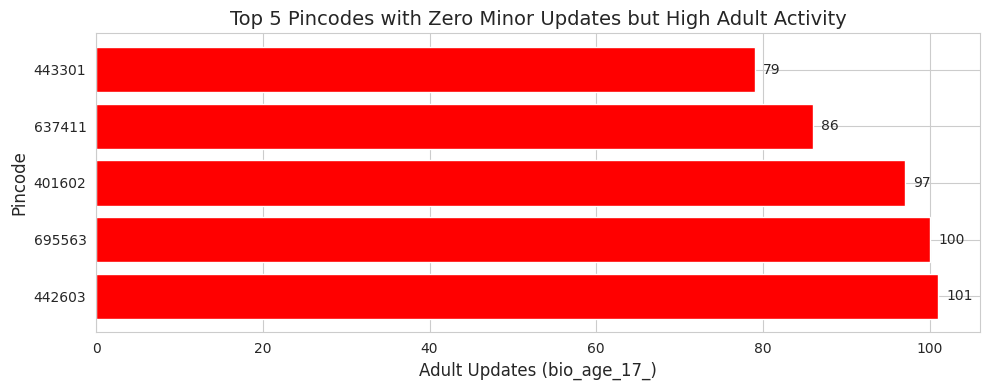

In [18]:
# Find pincodes where minor updates = 0 but adult updates > 50
anomalies = df[
    (df['bio_age_5_17'] == 0) &
    (df['bio_age_17_'] > 50)
].copy()

print("\n🔍 Potential Anomalies (Zero Minor Updates but High Adult Activity):")
if len(anomalies) > 0:
    print(anomalies[['state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_', 'total_bio']].head(10))
else:
    print("No anomalies found.")

# Plot top 5 anomalous pincodes
if len(anomalies) > 0:
    top_anomalies = anomalies.nlargest(5, 'bio_age_17_')[['state', 'district', 'pincode', 'bio_age_17_']]
    plt.figure(figsize=(10, 4))
    bars = plt.barh(top_anomalies['pincode'].astype(str), top_anomalies['bio_age_17_'], color='red')
    plt.title('Top 5 Pincodes with Zero Minor Updates but High Adult Activity', fontsize=14)
    plt.xlabel('Adult Updates (bio_age_17_)', fontsize=12)
    plt.ylabel('Pincode', fontsize=12)
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01 * max(top_anomalies['bio_age_17_']), bar.get_y() + bar.get_height()/2, int(width), ha='left', va='center')

    plt.tight_layout()
    plt.savefig('anomaly_pincodes.png', dpi=300, bbox_inches='tight')
    plt.show()

### H. Correlation Heatmap (Confirm Profiling Alerts)

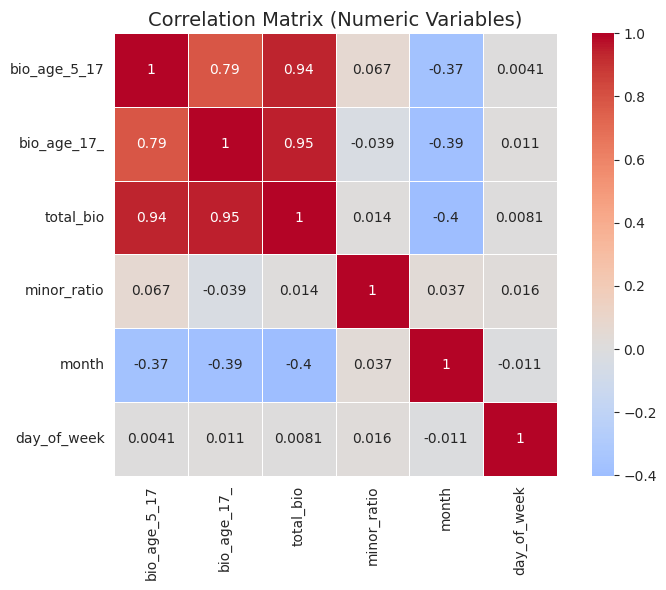

In [20]:
numeric_cols = ['bio_age_5_17', 'bio_age_17_', 'total_bio', 'minor_ratio', 'month', 'day_of_week']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Variables)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Detect Meaningful Anomalies

### A. Zero Minor Updates in High-Activity Areas

In [21]:
# Find districts with >100 total updates but 0 minor updates
zero_minor_districts = df[
    (df['bio_age_5_17'] == 0) &
    (df['total_bio'] >= 100)
].groupby(['state', 'district'])['total_bio'].sum().reset_index()

print("Districts with ZERO minor updates but high adult activity (≥100):")
print(zero_minor_districts.sort_values('total_bio', ascending=False).head(10))

Districts with ZERO minor updates but high adult activity (≥100):
         state            district  total_bio
1  Maharashtra          Gadchiroli        101
0       Kerala  Thiruvananthapuram        100


### B. Extreme Age Skew

In [22]:
# Districts where minor ratio < 0.01 (i.e., <1% minors)
extreme_skew = df.groupby(['state', 'district'])['minor_ratio'].mean().reset_index()
extreme_skew = extreme_skew[extreme_skew['minor_ratio'] < 0.01]

print("\nDistricts with extreme adult skew (<1% minor updates):")
print(extreme_skew.head(10))


Districts with extreme adult skew (<1% minor updates):
                 state   district  minor_ratio
229                Goa    Tiswadi          0.0
269            Haryana     Akhera          0.0
309    Jammu & Kashmir   Bandipur          0.0
313    Jammu & Kashmir     Kargil          0.0
315    Jammu & Kashmir    Kupwara          0.0
321    Jammu & Kashmir   Udhampur          0.0
322  Jammu and Kashmir          ?          0.0
347  Jammu and Kashmir   udhampur          0.0
535        Maharashtra  Hingoli *          0.0
624             Odisha     Anugal          0.0


### C. Sudden Drop in Updates (Temporal Anomaly)

In [23]:
# For top 5 states, check if any district had >500 updates one day, then 0 next day
top_states = df.groupby('state')['total_bio'].sum().nlargest(5).index
df_top = df[df['state'].isin(top_states)]

# Add next-day total per pincode
df_top = df_top.sort_values(['pincode', 'date'])
df_top['next_day_total'] = df_top.groupby('pincode')['total_bio'].shift(-1)

# Flag pincodes with drop from >200 to 0
sudden_drop = df_top[
    (df_top['total_bio'] > 200) &
    (df_top['next_day_total'] == 0)
][['state', 'district', 'pincode', 'date', 'total_bio']]

print("\nPotential service disruptions (sudden drop to zero):")
print(sudden_drop.head(10))


Potential service disruptions (sudden drop to zero):
Empty DataFrame
Columns: [state, district, pincode, date, total_bio]
Index: []


## all plots at once 

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import io

def generate_all_plots_and_zip(df, zip_filename='all_plots.zip'):
    """
    Generates multiple visualization plots from the DataFrame and saves them in a ZIP file.
    Expected column names:
    - date
    - state
    - district
    - pincode
    - bio_age_5_17
    - bio_age_17_
    """
    # Make a copy to avoid modifying original DataFrame
    df = df.copy()
    
    # Convert date column to datetime (handles DD-MM-YYYY format)
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')
    
    # Drop rows where date couldn't be parsed (optional - comment out if not needed)
    df = df.dropna(subset=['date'])
    
    plot_buffers = {}
    
    # ────────────────────────────────────────────────────────────────
    # 1. Time series line plot - total counts over time
    # ────────────────────────────────────────────────────────────────
    grouped_date = df.groupby('date')[['bio_age_5_17', 'bio_age_17_']].sum()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(grouped_date.index, grouped_date['bio_age_5_17'], label='Age 5-17', color='#1f77b4')
    ax.plot(grouped_date.index, grouped_date['bio_age_17_'], label='Age 17+', color='#ff7f0e')
    ax.set_title('Time Series - Total Counts by Age Group')
    ax.set_xlabel('Date')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['01_time_series_line.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 2. Bar chart - totals by state
    # ────────────────────────────────────────────────────────────────
    grouped_state = df.groupby('state')[['bio_age_5_17', 'bio_age_17_']].sum()
    fig, ax = plt.subplots(figsize=(10, 6))
    grouped_state.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('Total Counts by State')
    ax.set_ylabel('Count')
    ax.set_xlabel('State')
    plt.xticks(rotation=45, ha='right')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['02_state_bar.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 3. Overall pie chart - proportion of two age groups
    # ────────────────────────────────────────────────────────────────
    total_5_17 = df['bio_age_5_17'].sum()
    total_17_  = df['bio_age_17_'].sum()
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie([total_5_17, total_17_], 
           labels=['5–17 years', '17+ years'], 
           autopct='%1.1f%%', 
           colors=['#1f77b4', '#ff7f0e'],
           startangle=90)
    ax.set_title('Overall Distribution: Age 5-17 vs 17+')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['03_overall_pie.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 4. Top 10 districts - Age 5-17
    # ────────────────────────────────────────────────────────────────
    top_district_5_17 = df.groupby('district')['bio_age_5_17'].sum().nlargest(10)
    fig, ax = plt.subplots(figsize=(10, 6))
    top_district_5_17.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
    ax.set_title('Top 10 Districts – Age 5-17')
    ax.set_xlabel('Total Count')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['04_top10_district_5_17.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 5. Top 10 districts - Age 17+
    # ────────────────────────────────────────────────────────────────
    top_district_17 = df.groupby('district')['bio_age_17_'].sum().nlargest(10)
    fig, ax = plt.subplots(figsize=(10, 6))
    top_district_17.sort_values().plot(kind='barh', ax=ax, color='#ff7f0e')
    ax.set_title('Top 10 Districts – Age 17+')
    ax.set_xlabel('Total Count')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['05_top10_district_17_plus.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 6. Histogram - Age 5-17 distribution
    # ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 6))
    df['bio_age_5_17'].plot.hist(bins=40, ax=ax, color='#1f77b4', edgecolor='white')
    ax.set_title('Distribution of Values – bio_age_5_17')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['06_hist_5_17.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # 7. Histogram - Age 17+ distribution
    # ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 6))
    df['bio_age_17_'].plot.hist(bins=40, ax=ax, color='#ff7f0e', edgecolor='white')
    ax.set_title('Distribution of Values – bio_age_17_')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=130, bbox_inches='tight')
    buf.seek(0)
    plot_buffers['07_hist_17_plus.png'] = buf.read()
    plt.close(fig)
    
    # ────────────────────────────────────────────────────────────────
    # Save everything to ZIP
    # ────────────────────────────────────────────────────────────────
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for name, content in plot_buffers.items():
            zipf.writestr(name, content)
    
    print(f"ZIP file created successfully: {zip_filename}")
    print(f"Number of plots generated: {len(plot_buffers)}")
    print("Files inside:", list(plot_buffers.keys()))

In [13]:
generate_all_plots_and_zip(df)   # default name = all_plots.zip

ZIP file created successfully: all_plots.zip
Number of plots generated: 7
Files inside: ['01_time_series_line.png', '02_state_bar.png', '03_overall_pie.png', '04_top10_district_5_17.png', '05_top10_district_17_plus.png', '06_hist_5_17.png', '07_hist_17_plus.png']
